# TP – Thermique du passage au fin (lubrification loi puissance)

Ce TP fait suite au TP mécanique. Les profils de vitesse du passage au fin (Couette–Poiseuille loi puissance, entrefer variable) sont **supposés connus et fournis** : le code mécanique est donné clé en main dans les premières sections. Le couplage thermo-mécanique n'est pas traité dans ce cours.

L'objectif est de **résoudre numériquement l'équation de l'énergie** dans le domaine par une méthode de **différences finies** : advection en $x$ + diffusion en $y$ + dissipation visqueuse.

---
**Niveaux de guidage :**
- ⭐ Guidé – la formule est donnée, transcrire en Python
- ⭐⭐ Semi-guidé – stratégie expliquée, construction à compléter
- ⭐⭐⭐ Autonome – repartir des acquis pour généraliser


## 1. Import des bibliothèques


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq


## 2. Paramètres physiques

### Paramètres mécaniques

| Paramètre | Symbole | Valeur |
|-----------|---------|--------|
| Épaisseur film | $h$ | 1.0 m |
| Consistance | $K$ | 150 000 Pa·s$^n$ |
| Indice loi puissance | $n$ | 0.2 |
| Points verticaux | $N_y$ | 500 |

### Paramètres thermiques

| Paramètre | Symbole | Valeur |
|-----------|---------|--------|
| Masse volumique | $\\rho$ | 1000 kg/m³ |
| Capacité calorifique | $c_p$ | 2000 J/(kg·K) |
| Conductivité thermique | $k_{th}$ | 0.2 W/(m·K) |
| Température d'entrée | $T_0$ | 370 K |
| Température des parois | $T_w$ | 370 K |


In [3]:
# --- Mécanique ---
h  = 1.0
K  = 150000.0
n  = 0.2
Ny = 500
y  = np.linspace(0, h, Ny)

# --- Thermique ---
rho = 1000.0    # masse volumique [kg/m³]
cp  = 2000.0    # capacité calorifique [J/(kg·K)]
kth = 0.2       # conductivité thermique [W/(m·K)]

T0 = 370.0      # température d'entrée [K]
Tw = 370.0      # température des cylindres (parois isothermes) [K]


## 3. Résolution mécanique (code fourni)

Cette section reprend intégralement le Cas 4 du TP mécanique. **Aucun code à compléter ici** — exécutez simplement les cellules dans l'ordre.

À l'issue de cette section, vous disposerez de :
- `x_cyl`, `h_cyl` : géométrie de la calandre
- `S_x[i]`, `C_x[i]` : paramètres du profil de vitesse à chaque position $x_i$
- `cyl_velocity_profile(y, h, C, S, n, U_lower, U_upper)` : fonction de calcul du profil $u(y)$


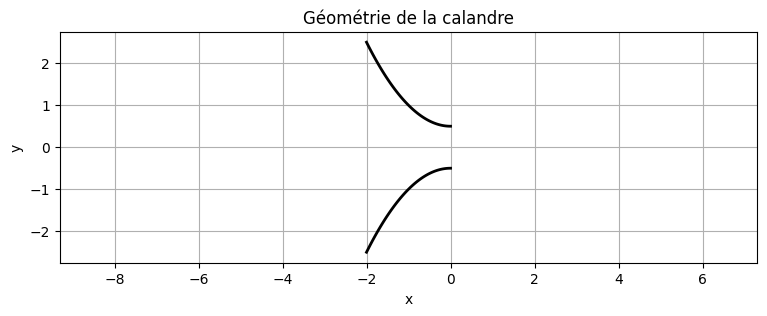

In [4]:
# --- Paramètres géométriques et cinématiques ---
friction  = 1.1
U_lower   = 0.5
U_upper   = U_lower * friction

Q_couette_0 = 0.5 * (U_lower + U_upper) * h
Q_cyl       = 1.2 * Q_couette_0

p = (n + 1) / n

R1 = 1.0; R2 = 1.0; h0 = 1.0
L  = 2.0; Nx = 80
x_cyl = np.linspace(-L, 0.001, Nx)
h_cyl = h0 + 0.5 * x_cyl**2 * (1/R1 + 1/R2)

plt.figure(figsize=(9, 3))
plt.plot(x_cyl, -h_cyl/2, 'k', lw=2)
plt.plot(x_cyl,  h_cyl/2, 'k', lw=2)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Géométrie de la calandre'); plt.axis('equal'); plt.grid(); plt.show()


In [5]:
# --- Fonctions de résolution mécanique ---

def solve_C_for_S(S, h, U0, Uh):
    def F(C): return S * (abs(h + C)**p - abs(C)**p) - (Uh - U0)
    return brentq(F, -10*h, 10*h)

def compute_Q_for_S(S, h, U0, Uh):
    C  = solve_C_for_S(S, h, U0, Uh)
    C2 = U0 - S * abs(C)**p
    y  = np.linspace(0, h, Ny)
    u  = S * abs(y + C)**p + C2
    return np.trapz(u, y)

def find_S_for_Q(h, U0, Uh, Q_target):
    Q_couette = 0.5 * (U0 + Uh) * h
    if abs(Q_target - Q_couette) < 1e-10: return 0.0
    Smin, Smax = -1.0, 1.0
    while (compute_Q_for_S(Smin, h, U0, Uh) - Q_target) * \
          (compute_Q_for_S(Smax, h, U0, Uh) - Q_target) > 0:
        Smin *= 2; Smax *= 2
    return brentq(lambda S: compute_Q_for_S(S, h, U0, Uh) - Q_target, Smin, Smax)

def cyl_velocity_profile(y, h, C, S, n, U_lower, U_upper):
    """
    Profil de vitesse Couette–Poiseuille loi puissance en repère physique y ∈ [0, h].
    """
    p  = (n + 1) / n
    C2 = U_lower - S * abs(C)**p
    return S * abs(y + C)**p + C2

# --- Résolution mécanique sur tout le domaine ---
C_x = np.zeros(Nx)
S_x = np.zeros(Nx)
for i in range(Nx):
    hi      = h_cyl[i]
    S_x[i]  = find_S_for_Q(hi, U_lower, U_upper, Q_cyl)
    C_x[i]  = solve_C_for_S(S_x[i], hi, U_lower, U_upper)

print("Résolution mécanique terminée.")


Résolution mécanique terminée.


## 4. Équation de l'énergie – formulation

Dans l'hypothèse de film mince (advection dominante en $x$, diffusion uniquement en $y$), l'équation de l'énergie s'écrit :

$$\rho c_p\, u(y)\, \frac{\partial T}{\partial x} = k_{th}\, \frac{\partial^2 T}{\partial y^2} + \Phi(y)$$

où le terme de **dissipation visqueuse** vaut (loi puissance) :

$$\Phi(y) = K\, \left|\frac{\partial u}{\partial y}\right|^{n+1}$$

### Conditions aux limites

- **Entrée** ($x = x_{\min}$) : $T(x_{\min}, y) = T_0$ (température uniforme imposée)
- **Parois** ($y = 0$ et $y = h$) : $T = T_w$ (cylindres isothermes, Dirichlet)

### Schéma numérique

On discrétise :
- Intégration en $x$ avec schéma Euler implicite (méthode des rectangles à droite)
- Diffusion en $y$ : schéma aux **différences finies centrées** d'ordre 2
$$\frac{\partial^2 T}{\partial y^2}\bigg|_{i,j} \approx \frac{T_{i,j-1} - 2T_{i,j} + T_{i,j+1}}{\Delta y^2}$$

En regroupant les inconnues $T_{i+1,j}$ (colonne suivante), on obtient à chaque pas en $x$ un **système linéaire tridiagonal** :

$$\mathbf{A}\, T_{i+1} = \mathbf{b}$$

avec, pour $1 \le j \le N_y - 2$ (points intérieurs) :

| Coefficient | Expression |
|-------------|------------|
| $A_{j,j-1}$ | $-k_{th}/\Delta y^2$ |
| $A_{j,j}$   | $2\,k_{th}/\Delta y^2 + \rho c_p\, u_j / \Delta x$ |
| $A_{j,j+1}$ | $-k_{th}/\Delta y^2$ |
| $b_j$       | $\rho c_p\, u_j\, T_{i,j}/\Delta x + \Phi_j$ |


## 5. Calcul de la dissipation visqueuse

> ⭐ **Question 1 (guidée)** – Complétez la fonction `dissipation` ci-dessous.
>
> Étapes :
> 1. Calculer le gradient $\partial u/\partial y$ avec `np.gradient(u, dy)`
> 2. Retourner $\Phi = K \cdot |\partial u / \partial y|^{n+1}$
>
> *Indice :* `np.abs(...)**(n+1)`


In [ ]:
def dissipation(u, dy, K, n):
    """
    Terme de dissipation visqueuse loi puissance : Phi = K * |du/dy|^(n+1)

    Paramètres
    ----------
    u  : array (Ny,) – profil de vitesse
    dy : float       – pas de grille en y
    K  : float       – consistance
    n  : float       – indice loi puissance

    Retour
    ------
    Phi : array (Ny,) – dissipation [W/m³]
    """
    # TODO ⭐ étape 1 : calculer dud_y = np.gradient(u, dy)
    dud_y = ...

    # TODO ⭐ étape 2 : retourner K * |dud_y|^(n+1)
    return ...


## 6. Construction de la matrice et du second membre

> ⭐⭐ **Question 2 (semi-guidée)** – Complétez `build_system` qui construit la matrice $\mathbf{A}$ et le vecteur $\mathbf{b}$ pour un pas en $x$.
>
> **Rappel des coefficients** (voir tableau section 4) :
> - Diagonale inférieure : $-k_{th}/\Delta y^2$
> - Diagonale principale : $2\,k_{th}/\Delta y^2 + \rho c_p\, u_j/\Delta x$
> - Diagonale supérieure : $-k_{th}/\Delta y^2$
> - Second membre : $\rho c_p\, u_j\, T_{i,j}/\Delta x + \Phi_j$
>
> Les conditions de Dirichlet aux parois ($j=0$ et $j=N_y-1$) sont déjà écrites pour vous.


In [ ]:
def build_system(T_col, u, Phi, dy, dx, Ny, kth, rho, cp, Tw):
    """
    Construit le système linéaire A*T_next = b pour un pas en x.

    Paramètres
    ----------
    T_col : array (Ny,) – température à la colonne courante T[i,:]
    u     : array (Ny,) – profil de vitesse à la colonne i
    Phi   : array (Ny,) – dissipation visqueuse à la colonne i
    dy    : float       – pas en y
    dx    : float       – pas en x (x[i+1] - x[i])
    Ny    : int         – nombre de points en y
    kth, rho, cp : paramètres thermiques
    Tw    : float       – température de paroi (Dirichlet)

    Retour
    ------
    A : array (Ny, Ny)
    b : array (Ny,)
    """
    A = np.zeros((Ny, Ny))
    b = np.zeros(Ny)

    # --- Points intérieurs ---
    for j in range(1, Ny-1):
        # TODO ⭐⭐ : remplir A[j, j-1], A[j, j], A[j, j+1] et b[j]
        A[j, j-1] = ...   # sous-diagonale
        A[j, j]   = ...   # diagonale
        A[j, j+1] = ...   # sur-diagonale
        b[j]      = ...   # second membre

    # --- Condition Dirichlet en y=0 (paroi inférieure) ---
    A[0, 0] = 1.0
    b[0]    = Tw

    # --- Condition Dirichlet en y=h (paroi supérieure) ---
    A[-1, -1] = 1.0
    b[-1]     = Tw

    return A, b


## 7. Boucle de marche en x

On intègre l'équation de l'énergie pas à pas en $x$, de l'entrée ($x_{\\min}$) vers la sortie.

À chaque pas $i$ :
1. Calculer $u(y)$ à partir de `cyl_velocity_profile`
2. Calculer $\Phi(y)$ avec `dissipation`
3. Construire $\mathbf{A}$ et $\mathbf{b}$ avec `build_system`
4. Résoudre $\mathbf{A}\, T_{i+1} = \mathbf{b}$ avec `np.linalg.solve`

> ⭐⭐ **Question 3 (semi-guidée)** – Complétez la boucle ci-dessous en appelant les fonctions construites aux questions 1 et 2.
>
> Les initialisations (`T`, condition initiale, `dx`, `dy`) sont déjà écrites.


In [ ]:
# --- Initialisation de la grille thermique ---
T = np.zeros((Nx, Ny))
T[0, :] = T0   # condition initiale : température uniforme à l'entrée

# --- Boucle de marche en x ---
for i in range(Nx - 1):

    dx = x_cyl[i+1] - x_cyl[i]
    hi = h_cyl[i]

    # Grille locale en y
    y_loc = np.linspace(0.0, hi, Ny)
    dy    = y_loc[1] - y_loc[0]

    # TODO ⭐⭐ étape 1 : calculer le profil de vitesse u avec cyl_velocity_profile
    u = ...

    # TODO ⭐⭐ étape 2 : calculer la dissipation Phi avec la fonction dissipation
    Phi = ...

    # TODO ⭐⭐ étape 3 : construire A et b avec build_system
    A, b = ...

    # TODO ⭐⭐ étape 4 : résoudre A*T[i+1,:] = b avec np.linalg.solve
    T[i+1, :] = ...

print("Résolution thermique terminée.")
print(f"T max = {T.max():.2f} K  |  T min = {T.min():.2f} K")


## 8. Visualisation de la cartographie T(x, y)

La visualisation utilise `tricontourf` (triangulation non structurée) pour s'adapter à l'entrefer variable $h(x)$.
Ce code est fourni : exécutez-le après avoir complété la boucle.


In [ ]:
from matplotlib.tri import Triangulation

X_pts, Y_pts, T_pts = [], [], []

for i in range(len(x_cyl)):
    xi     = x_cyl[i]
    hi     = h_cyl[i]
    y_phys = np.linspace(0.0, hi, Ny)
    y_plot = y_phys - hi/2   # recentrage pour la visu

    X_pts.extend(xi * np.ones_like(y_plot))
    Y_pts.extend(y_plot)
    T_pts.extend(T[i, :])

X_pts = np.array(X_pts)
Y_pts = np.array(Y_pts)
T_pts = np.array(T_pts)

tri  = Triangulation(X_pts, Y_pts)
mask = np.zeros(len(tri.triangles), dtype=bool)
for k, tri_idx in enumerate(tri.triangles):
    x_c   = X_pts[tri_idx].mean()
    y_c   = Y_pts[tri_idx].mean()
    h_loc = np.interp(x_c, x_cyl, h_cyl)
    if not (-h_loc/2 <= y_c <= h_loc/2):
        mask[k] = True
tri.set_mask(mask)

plt.figure(figsize=(9, 4))
plt.plot(x_cyl, -h_cyl/2, 'k', lw=2)
plt.plot(x_cyl,  h_cyl/2, 'k', lw=2)
cont = plt.tricontourf(tri, T_pts, levels=50, cmap='coolwarm')
plt.colorbar(cont, label='T(x,y) [K]')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Cartographie de la température T(x,y)')
plt.grid(); plt.show()


## 9. Analyse des résultats

> ⭐⭐ **Question 4 (semi-guidée)** – Tracez le profil de température $T(y)$ à quelques positions $x$ caractéristiques (entrée, milieu, sortie) sur un même graphique.
>
> *Indice :* utilisez `T[i, :]` pour la colonne $i$, et `y_loc = np.linspace(0, h_cyl[i], Ny)` pour l'axe $y$.
>
> Observez et commentez : la dissipation crée-t-elle un pic de température au centre ? Où est-il le plus marqué ?


In [ ]:
# TODO ⭐⭐ : tracer T(y) pour i = 0, Nx//2, Nx-1 sur un même graphe
# Indice : utilisez plt.plot(T[i, :], y_loc, label=f'x={x_cyl[i]:.2f}')

fig, ax = plt.subplots(figsize=(6, 5))

for i in [0, Nx//4, Nx//2, 3*Nx//4, Nx-1]:
    y_loc = ...   # TODO ⭐⭐ : grille locale en y pour la colonne i
    # TODO ⭐⭐ : tracer T[i,:] en fonction de y_loc
    ax.plot(..., ..., label=f'x = {x_cyl[i]:.2f}')

ax.set_xlabel('T [K]')
ax.set_ylabel('y [m]')
ax.set_title('Profils de température à différentes positions x')
ax.legend()
ax.grid()
plt.show()


## 10. Pour aller plus loin (optionnel)

> ⭐⭐⭐ **Question 5 – Sensibilité à la conductivité thermique**
>
> Relancez la simulation avec $k_{th} = 0.02$ W/(m·K) (fluide peu conducteur) puis $k_{th} = 2.0$ W/(m·K).
> Que se passe-t-il sur l'échauffement maximal et sa localisation ?
>
> ⭐⭐⭐ **Question 6 – Température de paroi variable**
>
> Modifiez le code pour imposer $T_w = 350$ K (parois froides) avec $T_0 = 370$ K (fluide plus chaud à l'entrée).
> Observez l'effet de refroidissement par les cylindres.
>
> ⭐⭐⭐ **Question 7 – Nombre de Péclet thermique**
>
> Le nombre de Péclet compare l'advection à la diffusion :
> $$Pe = \frac{\rho c_p\, U_{\text{moy}}\, h_0}{k_{th}}$$
> Calculez $Pe$ pour les paramètres du TP. Que prédit-il sur le rôle relatif de l'advection et de la diffusion ?
> Vérifiez qualitativement sur vos cartographies.
